In [1]:
import glob

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
indir = "/Users/hwunrow/Documents/GitHub/cgnn/data/raw/advan_plus/dewey-downloads/weekly-patterns-plus"
# files = glob.glob(f"{indir}/2020-07-13*.snappy.parquet")
# print(len(files))

# advan_plus_df = pd.read_parquet(files[0])
# advan_plus_df.head()

In [ ]:
from cgnn.process_xwalk import get_zip_cbsa_map

zip_cbsa_map = get_zip_cbsa_map()
johnson_city_zips = zip_cbsa_map.loc[zip_cbsa_map["CBSA"] == "27740", "ZIP"].values

In [39]:
advan_plus_df.columns

Index(['BRAND', 'BUCKETED_DWELL_TIMES', 'CITY', 'CLOSE_DATE', 'DATE_RANGE_END',
       'DATE_RANGE_START', 'DEVICE_TYPE', 'DISTANCE_FROM_HOME', 'FOOTPRINT_ID',
       'ID_STORE', 'ISO_COUNTRY_CODE', 'IS_DISTRIBUTOR', 'LATITUDE',
       'LOCATION_NAME', 'LONGITUDE', 'MEDIAN_DWELL', 'MSA_CODE', 'NAICS_CODE',
       'OPEN_DATE', 'PERSISTENT_ID', 'PERSISTENT_ID_STORE', 'POI_CBG',
       'POSTAL_CODE', 'REGION', 'RELATED_SAME_DAY_BRAND',
       'RELATED_SAME_WEEK_BRAND', 'RESERVED1', 'RESERVED2', 'RESERVED3',
       'RESERVED4', 'RESERVED5', 'STREET_ADDRESS', 'SUB_CATEGORY', 'TICKER',
       'TOP_CATEGORY', 'VISITOR_COUNTRY_OF_ORIGIN', 'VISITOR_COUNTS',
       'VISITOR_DAYTIME_CBGS', 'VISITOR_HOME_AGGREGATION', 'VISITOR_HOME_CBGS',
       'VISITS_BY_DAY', 'VISITS_BY_EACH_HOUR', 'VISIT_COUNTS'],
      dtype='object')

In [80]:
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)


columns = ['PERSISTENT_ID', 'ID_STORE', 'PERSISTENT_ID_STORE', 'CITY', 'LOCATION_NAME', 'POSTAL_CODE', 'STREET_ADDRESS', 'VISITOR_COUNTS', 'NAICS_CODE']
# advan_plus_df.loc[(advan_plus_df['POSTAL_CODE'].isin(johnson_city_zips)) & (advan_plus_df['TOP_CATEGORY'] == 'Death Care Services '), columns]
# advan_plus_df.loc[(advan_plus_df['POSTAL_CODE'].isin(johnson_city_zips)) & (advan_plus_df['CITY'] == 'Hampton'), columns]
# advan_plus_df.loc[(advan_plus_df['POSTAL_CODE'].isin(johnson_city_zips)) & (advan_plus_df['NAICS_CODE'].str.contains('812220')), columns]
advan_plus_df.loc[(advan_plus_df['POSTAL_CODE'].isin(johnson_city_zips)) & (advan_plus_df['CITY'].str.contains('Roan Mountain')), columns]
# Buck Mountain Road	

,PERSISTENT_ID,ID_STORE,PERSISTENT_ID_STORE,CITY,LOCATION_NAME,POSTAL_CODE,STREET_ADDRESS,VISITOR_COUNTS,NAICS_CODE
393397,A1_SUBWAY,1433226,1433226,Roan Mountain,Subway,37687,8369 Highway 19E,366,722513
494690,A1_NAICS-444110,10774869,10774869,Roan Mountain,Home Centers,37687,347 Fork Mountain Rd,40,444110
501325,A1_NAICS-441110,10201408,10201408,Roan Mountain,New Car Dealers,37687,290 Heaton Creek Rd,20,441110
799762,A1_NAICS-423210,9560239,9560239,Roan Mountain,Furniture Merchant Wholesalers,37687,330 Heaton Ridge Rd,20,423210
842712,A1_BP,1721016,1721016,Roan Mountain,BP p.l.c.,37687,8166 Hwy 19 East,1872,447110
1353058,A1_NAICS-444110,11078119,11078119,Roan Mountain,Home Centers,37687,136 Miller Hollow Rd,203,444110
1837548,A1_NAICS-238220,10511154,10511154,Roan Mountain,"Plumbing, Heating, and Air-Conditioning Contra...",37687,174 Carter St,448,238220
1913975,A1_GPM-A-FASMA,6998025,6998025,Roan Mountain,fas mart,37687,8369 Highway 19E,446,445120
1924042,A1_AFI,4453986,4453986,Roan Mountain,"Armstrong Flooring, Inc.",37687,8497 Hwy 19 E,162,321918
2083670,A1_NAICS-812112,9381389,9381389,Roan Mountain,Beauty Salons,37687,116 Hampton Creek Rd,61,812112


In [79]:
cols = advan_plus_df.columns.tolist()
cols.sort()
print(cols)


['BRAND', 'BUCKETED_DWELL_TIMES', 'CITY', 'CLOSE_DATE', 'DATE_RANGE_END', 'DATE_RANGE_START', 'DEVICE_TYPE', 'DISTANCE_FROM_HOME', 'FOOTPRINT_ID', 'ID_STORE', 'ISO_COUNTRY_CODE', 'IS_DISTRIBUTOR', 'LATITUDE', 'LOCATION_NAME', 'LONGITUDE', 'MEDIAN_DWELL', 'MSA_CODE', 'NAICS_CODE', 'OPEN_DATE', 'PERSISTENT_ID', 'PERSISTENT_ID_STORE', 'POI_CBG', 'POSTAL_CODE', 'REGION', 'RELATED_SAME_DAY_BRAND', 'RELATED_SAME_WEEK_BRAND', 'RESERVED1', 'RESERVED2', 'RESERVED3', 'RESERVED4', 'RESERVED5', 'STREET_ADDRESS', 'SUB_CATEGORY', 'TICKER', 'TOP_CATEGORY', 'VISITOR_COUNTRY_OF_ORIGIN', 'VISITOR_COUNTS', 'VISITOR_DAYTIME_CBGS', 'VISITOR_HOME_AGGREGATION', 'VISITOR_HOME_CBGS', 'VISITS_BY_DAY', 'VISITS_BY_EACH_HOUR', 'VISIT_COUNTS']


In [34]:
advan_plus_df.VISITOR_HOME_AGGREGATION.isna().sum()

np.int64(2005289)

In [32]:
advan_plus_df.ISO_COUNTRY_CODE.value_counts()

ISO_COUNTRY_CODE
US    4935167
CA     156055
Name: count, dtype: int64

In [3]:
advan_plus_agg_df = advan_plus_df.groupby('POSTAL_CODE')['VISITOR_COUNTS'].sum().reset_index()
del advan_plus_df
advan_plus_agg_df.head()

,POSTAL_CODE,VISITOR_COUNTS
0,,1160
1,48104,2055
2,75229nn,203
3,S7H 4X4,211
4,00000,1668


In [4]:
# Read in shared POI mapping
shared_poi_df = pd.read_csv("/Users/hwunrow/Documents/GitHub/cgnn/data/raw/advan/patterns-shared-polygon-info.csv")

# Read in advan data
indir = "/Users/hwunrow/Documents/GitHub/cgnn/data/raw/advan/dewey-downloads/weekly-patterns"
files = glob.glob(f"{indir}/2020-07-13*.csv.gz")
print(len(files))

columns = ['placekey', 'location_name', 'postal_code','naics_code', 'raw_visitor_counts']

all_advan_df = []
for file in tqdm(files):
    df = pd.read_csv(file, dtype={"postal_code": str, 'naics_code': str}, usecols=columns)
    df = df.loc[~(df['placekey'].isin(shared_poi_df['PLACEKEY_SHARED']))]
    all_advan_df.append(df)

all_advan_df = pd.concat(all_advan_df, axis=0, ignore_index=True)

500


100%|██████████| 500/500 [13:23<00:00,  1.61s/it]


In [5]:
advan_agg_df = all_advan_df.groupby('postal_code').raw_visitor_counts.sum().reset_index()
del all_advan_df
advan_agg_df.head()

,postal_code,raw_visitor_counts
0,00000,1423.0
1,00233,8.0
2,00321,0.0
3,00404,0.0
4,00501,41.0


In [6]:
merged_df = advan_agg_df.merge(advan_plus_agg_df, left_on='postal_code', right_on='POSTAL_CODE', how='inner')
merged_df.rename(columns={'raw_visitor_counts': 'raw_visitor_counts_advan', 'VISITOR_COUNTS': 'raw_visitor_counts_advan_plus'}, inplace=True)

In [7]:
merged_df.head()

,postal_code,raw_visitor_counts_advan,POSTAL_CODE,raw_visitor_counts_advan_plus
0,00000,1423.0,00000,5148
1,00501,41.0,00501,1546
2,00603,0.0,00603,346
3,00610,0.0,00610,1628
4,00611,0.0,00611,527


In [8]:
merged_df[['raw_visitor_counts_advan', 'raw_visitor_counts_advan_plus']].sum()

raw_visitor_counts_advan         346319711.0
raw_visitor_counts_advan_plus     5374714295
dtype: object

In [15]:
merged_df['ratio'] = merged_df['raw_visitor_counts_advan_plus'].astype(float) / merged_df['raw_visitor_counts_advan']

finite_ratio = merged_df.loc[merged_df['ratio'].apply(lambda x: np.isfinite(x)), 'ratio']
finite_ratio.describe()

count    71700.000000
mean        92.903725
std        572.366677
min          0.000308
25%         12.796975
50%         25.038350
75%         70.166667
max      40380.000000
Name: ratio, dtype: float64

In [19]:
merged_df[(merged_df['ratio'] > 40000) & (merged_df['ratio'].apply(lambda x: np.isfinite(x)))]

,postal_code,raw_visitor_counts_advan,POSTAL_CODE,raw_visitor_counts_advan_plus,ratio
46368,L1N,1.0,L1N,40272,40272.0
67545,T6T 1H9,1.0,T6T 1H9,40380,40380.0


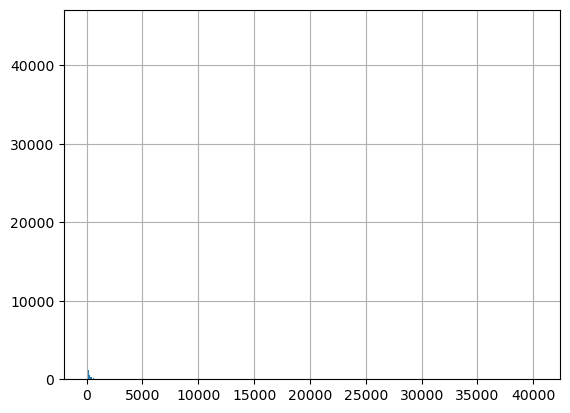

In [14]:
# Filter for finite ratio values and plot histogram
finite_ratio = merged_df.loc[merged_df['ratio'].apply(lambda x: np.isfinite(x)), 'ratio']
finite_ratio.hist(bins=1000)
plt.show()

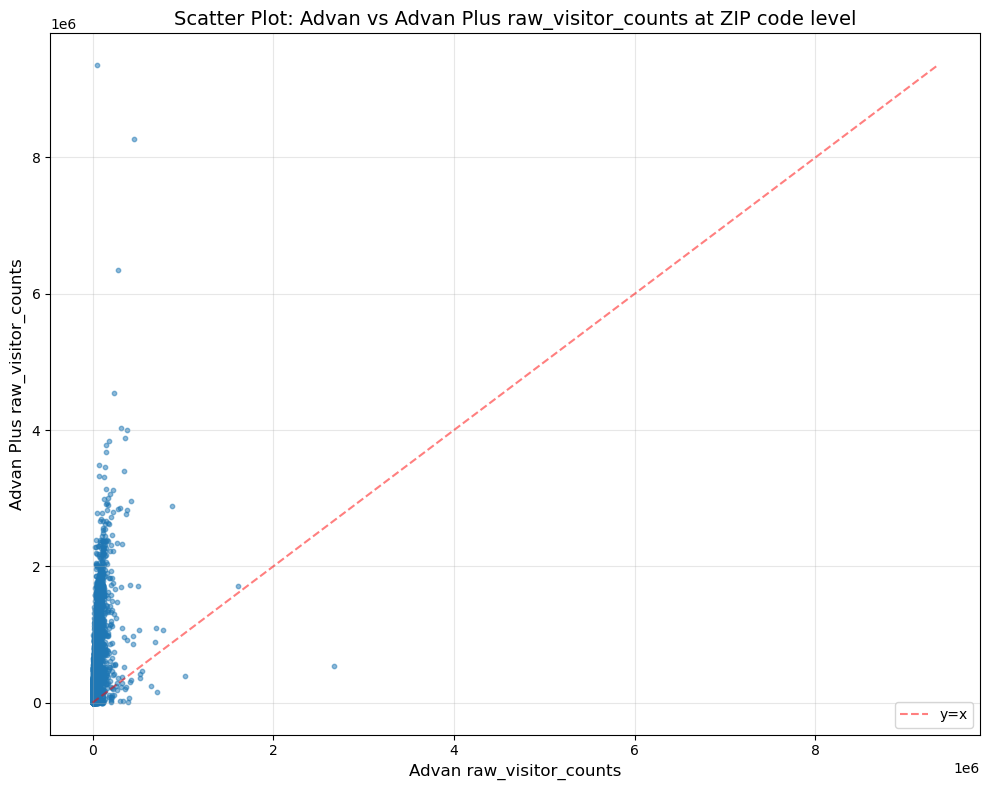

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    merged_df['raw_visitor_counts_advan'],
    merged_df['raw_visitor_counts_advan_plus'],
    alpha=0.5,
    s=10,
)

plt.xlabel('Advan raw_visitor_counts', fontsize=12)
plt.ylabel('Advan Plis raw_visitor_counts', fontsize=12)
plt.title('Scatter Plot: Advan vs Advan Plus raw_visitor_counts at ZIP code level', fontsize=14)
plt.grid(True, alpha=0.3)

# Add diagonal line for reference
max_val = max(
    merged_df['raw_visitor_counts_advan'].max(),
    merged_df['raw_visitor_counts_advan_plus'].max()
)
min_val = min(
    merged_df['raw_visitor_counts_advan'].min(),
    merged_df['raw_visitor_counts_advan_plus'].min()
)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
plt.legend()

# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Advan raw_visitor_counts', fontsize=12)
plt.ylabel('Advan Plus raw_visitor_counts', fontsize=12)

plt.tight_layout()
plt.show()

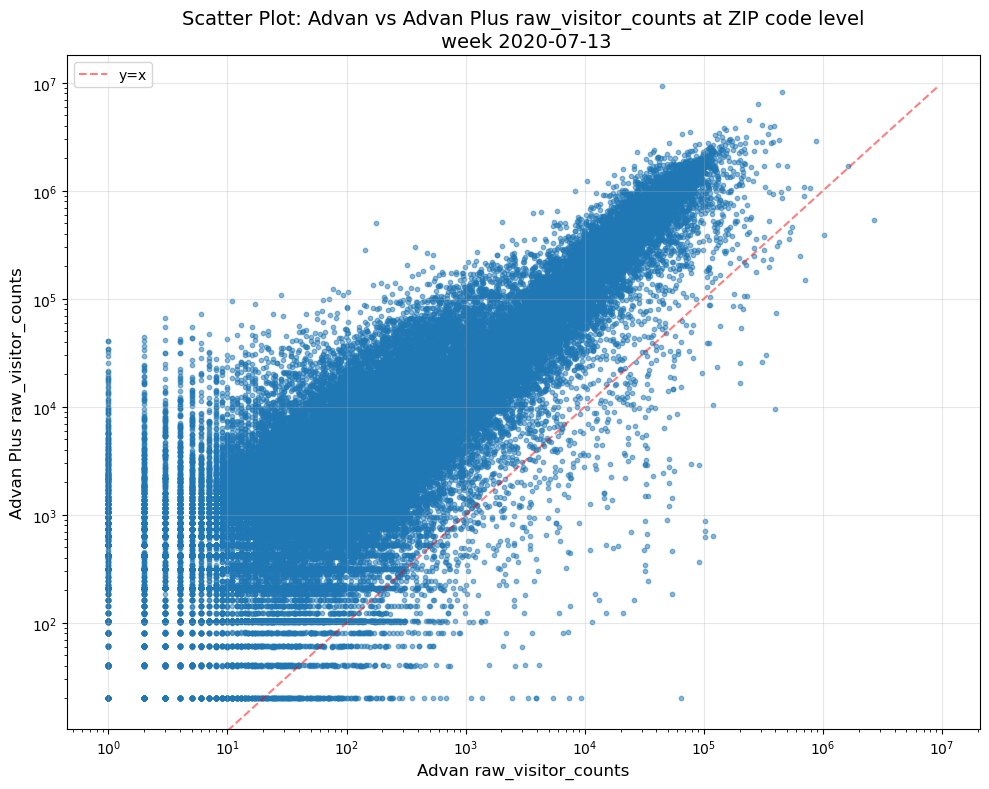

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    merged_df['raw_visitor_counts_advan'],
    merged_df['raw_visitor_counts_advan_plus'],
    alpha=0.5,
    s=10,
)

plt.xlabel('Advan raw_visitor_counts', fontsize=12)
plt.ylabel('Advan Plis raw_visitor_counts', fontsize=12)
plt.title('Scatter Plot: Advan vs Advan Plus raw_visitor_counts at ZIP code level\n week 2020-07-13', fontsize=14)
plt.grid(True, alpha=0.3)

# Add diagonal line for reference
max_val = max(
    merged_df['raw_visitor_counts_advan'].max(),
    merged_df['raw_visitor_counts_advan_plus'].max()
)
min_val = min(
    merged_df['raw_visitor_counts_advan'].min(),
    merged_df['raw_visitor_counts_advan_plus'].min()
)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Advan raw_visitor_counts', fontsize=12)
plt.ylabel('Advan Plus raw_visitor_counts', fontsize=12)

plt.tight_layout()
plt.show()